<a href="https://colab.research.google.com/github/Yuvraj5027/Generative-AI/blob/main/Assignment_6_Style_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6: Applying AI-Based Style Transfer to an Image

**Objective:** Compare two methods of image style transfer on the same photo.

- **Method 1:** CycleGAN (pretrained Van Gogh model)
- **Method 2:** Neural Style Transfer using VGG19 (style of Van Gogh's *The Starry Night*)

**Before running:** upload one photo (a landscape, building or object) and name it `content.jpg`. In Google Colab, use the Files panel on the left. Turn on a GPU from Runtime > Change runtime type for faster Neural Style Transfer.

## Step 1: Install and import the libraries

`dominate` is a small library needed by the CycleGAN code. The other libraries are PyTorch, torchvision, PIL and matplotlib.

In [1]:
!pip install -q dominate

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
size = 256
print("Using:", device)

Using: cuda


## Step 2: Load the original image

The image is resized to 256 x 256 pixels. CycleGAN was trained on images of this size, and using the same size for both methods keeps the comparison fair.

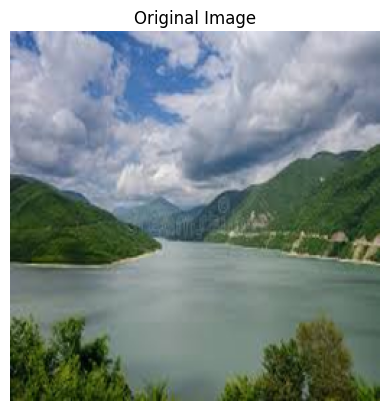

In [2]:
os.makedirs("input_images", exist_ok=True)

original = Image.open("content.jpg").convert("RGB").resize((size, size))
original.save("input_images/content.jpg")

plt.imshow(original)
plt.axis("off")
plt.title("Original Image")
plt.show()

## Method 1: CycleGAN

**What is CycleGAN?** CycleGAN learns to change images from one group (domain) to another, for example photos to Van Gogh paintings. It does not need matching pairs of photos and paintings. It has two generators:

- **G** turns a photo into a painting.
- **F** turns a painting back into a photo.

**Cycle consistency:** If we turn a photo into a painting with G and then turn that painting back with F, we should get the original photo again. The training punishes the model when the returned photo is different from the starting photo. This forces the generator to keep the content (shapes and objects) of the image and change only the style.

We use the pretrained `style_vangogh` model from the official CycleGAN repository, so no training is needed.

In [3]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
!cd pytorch-CycleGAN-and-pix2pix && bash ./scripts/download_cyclegan_model.sh style_vangogh

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 33.19 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_vangogh]
for details.

--2026-10-04 18:23:20--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_vangogh.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43

Now we run the pretrained model on our image. The result is saved inside the `results` folder.

In [6]:
!python pytorch-CycleGAN-and-pix2pix/test.py --dataroot input_images --name style_vangogh_pretrained --model test --dataset_mode single --no_dropout --preprocess none --checkpoints_dir pytorch-CycleGAN-and-pix2pix/checkpoints --results_dir results

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: pytorch-CycleGAN-and-pix2pix/checkpoints	[default: ./checkpoints]
                crop_size: 256                           
                 dataroot: input_images                  	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
        

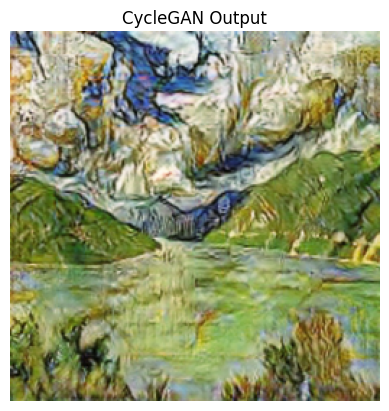

In [7]:
cyclegan_output = Image.open("results/style_vangogh_pretrained/test_latest/images/content_fake.png").convert("RGB")

plt.imshow(cyclegan_output)
plt.axis("off")
plt.title("CycleGAN Output")
plt.show()

## Method 2: Neural Style Transfer (VGG19)

**How it works:** A VGG19 network that was already trained on ImageNet is used only to measure images. We start with a copy of the original image and change its pixels step by step to reduce two losses:

- **Content loss:** keeps the features of the new image close to the features of the original image, so the objects stay in place.
- **Style loss:** keeps the texture and colour patterns of the new image close to those of the painting. Texture is measured with a **Gram matrix**, which tells us which features appear together.

First, download the painting that gives the style.

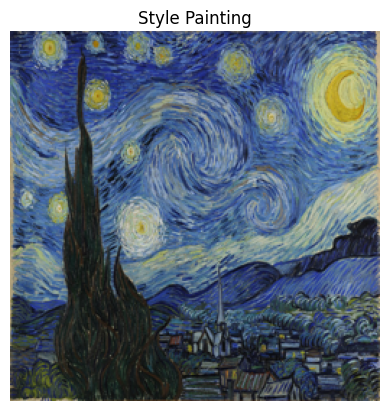

In [8]:
!wget -q -U "Mozilla/5.0" -O style.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"

style_picture = Image.open("style.jpg").convert("RGB").resize((size, size))

plt.imshow(style_picture)
plt.axis("off")
plt.title("Style Painting")
plt.show()

Next, load the pretrained VGG19 and freeze it, because we only use it to read features and do not want to train it.

In [9]:
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

for layer in vgg:
    if isinstance(layer, nn.ReLU):
        layer.inplace = False

for parameter in vgg.parameters():
    parameter.requires_grad_(False)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 145MB/s]


Helper functions:

- `to_tensor` converts a picture into a tensor.
- `get_features` passes the image through VGG19 and collects the outputs of chosen layers.
- `gram_matrix` measures the style of a feature map.

In [10]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

content_layer = 22
style_layers = [1, 6, 11, 20, 29]

def to_tensor(picture):
    return transforms.ToTensor()(picture).unsqueeze(0).to(device)

def get_features(image):
    x = (image - mean) / std
    features = {}
    for number, layer in enumerate(vgg):
        x = layer(x)
        if number == content_layer or number in style_layers:
            features[number] = x
    return features

def gram_matrix(feature):
    _, channels, height, width = feature.size()
    flat = feature.view(channels, height * width)
    return flat @ flat.t() / (channels * height * width)

Prepare the images and calculate the target content features and target style features once.

In [11]:
content_image = to_tensor(original)
style_image = to_tensor(style_picture)

content_features = get_features(content_image)
style_features = get_features(style_image)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_layers}

Now we run the optimisation. The new image starts as a copy of the original and the Adam optimiser changes its pixels for 400 steps.

- `style_weight` is large so that the style becomes visible.
- `content_weight` keeps the original shapes.

In [12]:
new_image = content_image.clone().requires_grad_(True)
optimizer = optim.Adam([new_image], lr=0.02)

content_weight = 1
style_weight = 1000000

for step in range(1, 401):
    optimizer.zero_grad()
    new_features = get_features(new_image)

    content_loss = torch.mean((new_features[content_layer] - content_features[content_layer]) ** 2)

    style_loss = 0
    for layer in style_layers:
        new_gram = gram_matrix(new_features[layer])
        style_loss = style_loss + torch.mean((new_gram - style_grams[layer]) ** 2)

    total_loss = content_weight * content_loss + style_weight * style_loss
    total_loss.backward()
    optimizer.step()

    new_image.data.clamp_(0, 1)

    if step % 100 == 0:
        print("Step", step, "Total loss:", round(total_loss.item(), 4))

Step 100 Total loss: 8.3073
Step 200 Total loss: 7.1346
Step 300 Total loss: 6.7438
Step 400 Total loss: 6.5396


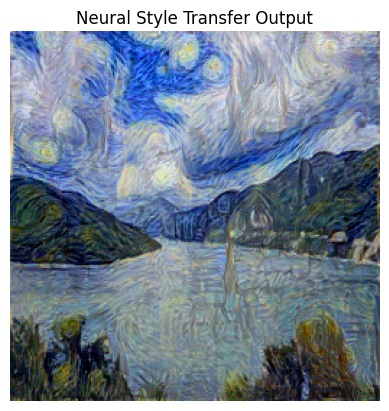

In [13]:
nst_output = transforms.ToPILImage()(new_image.detach().squeeze(0).cpu())

plt.imshow(nst_output)
plt.axis("off")
plt.title("Neural Style Transfer Output")
plt.show()

## Results: all three images side by side

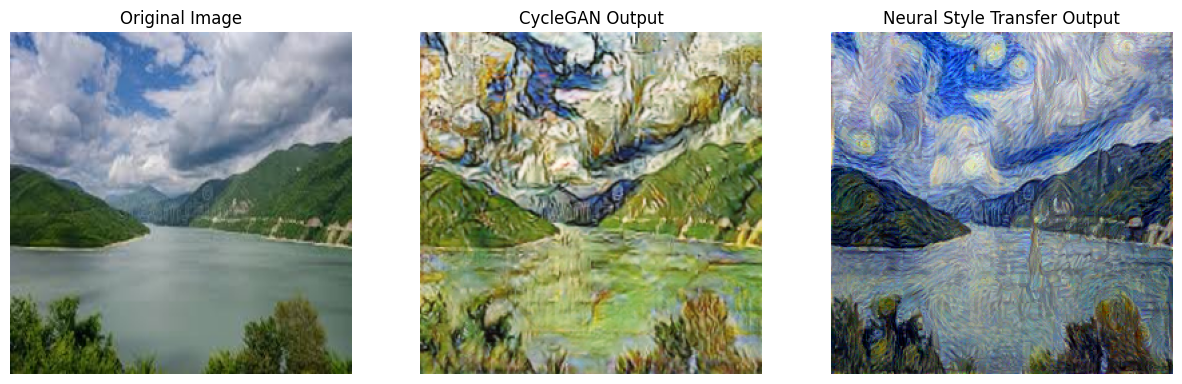

In [14]:
images = [original, cyclegan_output, nst_output]
titles = ["Original Image", "CycleGAN Output", "Neural Style Transfer Output"]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.savefig("comparison.png", bbox_inches="tight")
plt.show()

## Written Comparison

Neural Style Transfer preserved the original content better: the mountains, lake, shoreline and trees are still clearly recognisable, whereas CycleGAN turned the clouds into abstract blobs, although it kept the original green colours of the hills and water. Neural Style Transfer also produced the stronger style transformation, because it copied the swirling blue sky, star-like circles and brush strokes of The Starry Night over the whole image, while CycleGAN gave a more general Van Gogh look with thick outlines. CycleGAN uses cycle consistency, meaning a painting converted back should give the original photo, which is meant to protect the content, but it is a loose guide and does not keep every detail, as the changed sky shows. The main difference is that CycleGAN learns the overall style of a painter from many paintings and works in one fast step, while Neural Style Transfer copies one chosen painting and needs hundreds of optimisation steps.